<a href="https://colab.research.google.com/github/SarathKasturi16/Mental-Health-Prediction-/blob/main/script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Project: Mental Health Analysis
Predicting a Person’s Need for Mental Health Treatment Using Lifestyle and Stress Factors

## 1.1 Imports and loading the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder


In [ ]:
df = pd.read_csv('Mental Health Dataset.csv')
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


## 1.2 Basic EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [ ]:
df.nunique()

Timestamp                  580
Gender                       2
Country                     35
Occupation                   5
self_employed                2
family_history               2
treatment                    2
Days_Indoors                 5
Growing_Stress               3
Changes_Habits               3
Mental_Health_History        3
Mood_Swings                  3
Coping_Struggles             2
Work_Interest                3
Social_Weakness              3
mental_health_interview      3
care_options                 3
dtype: int64

In [ ]:
df['self_employed'].value_counts()

self_employed
No     257994
Yes     29168
Name: count, dtype: int64

In [ ]:
df['self_employed'].isnull().sum()

5202

In [ ]:
df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)
df['self_employed'].isnull().sum()

C:\Users\magan\AppData\Local\Temp\ipykernel_112388\1458857347.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)


0

In [ ]:
df.duplicated().sum()

2313

In [ ]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

0

## 1.3 Visualisations

The Visualisation will be mainly based to support my question *"Predicting a Person’s Need for Mental Health Treatment Using Lifestyle and Stress Factors"*

So my target variable is 'treatment'

### 1.3.1 Univariate Analysis

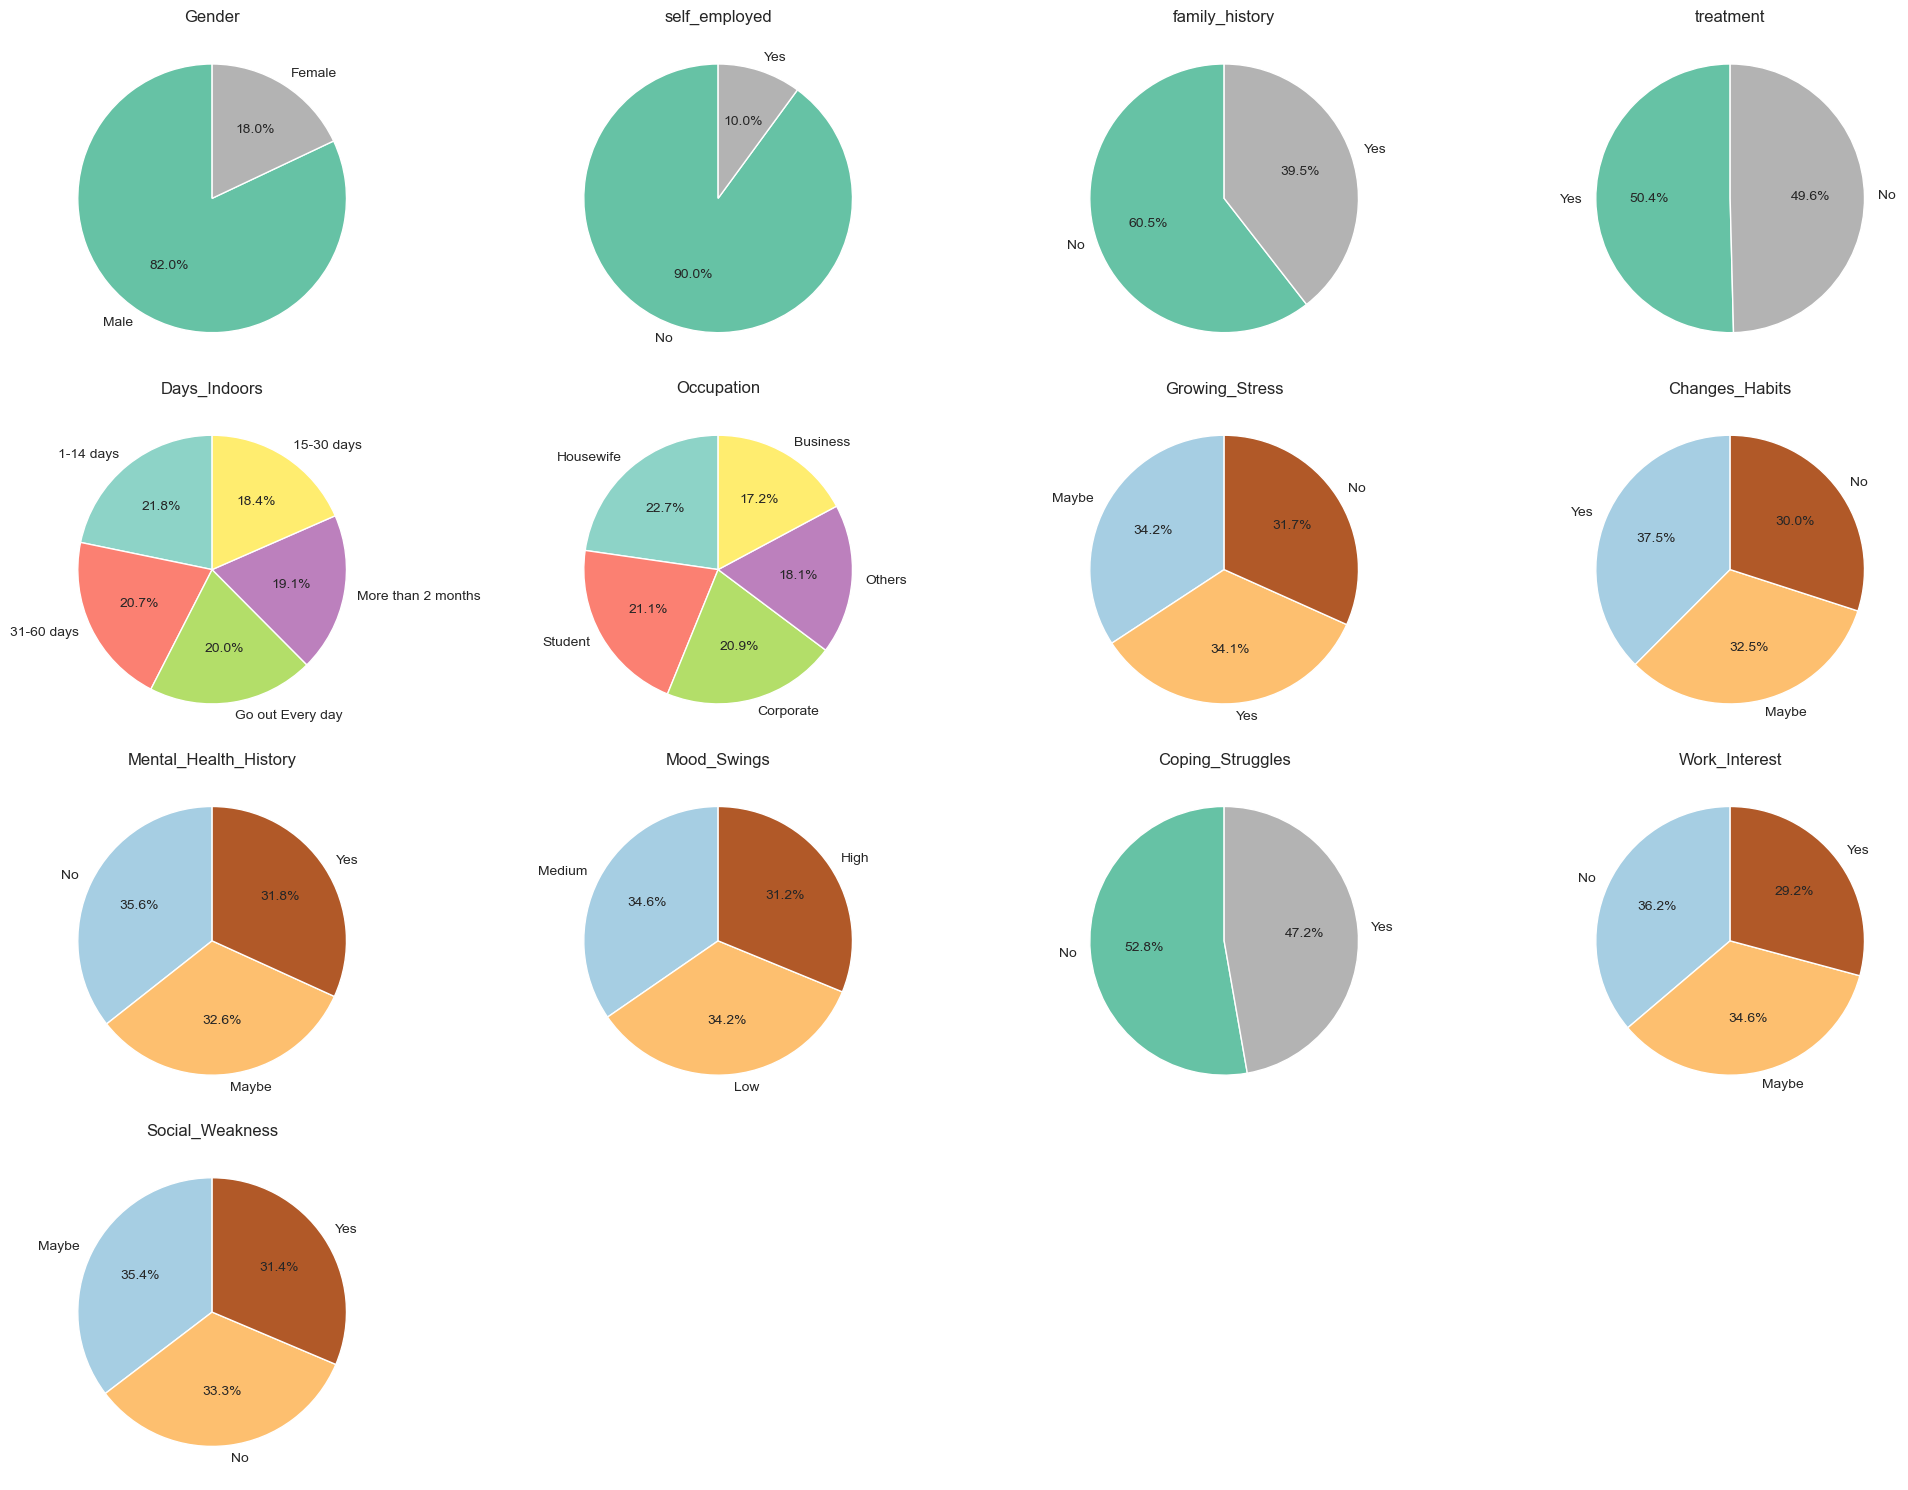

In [ ]:
sns.set_style("whitegrid")

cols_to_visualize = ['Gender','self_employed','family_history', 'treatment', 'Days_Indoors','Occupation',
                     'Growing_Stress','Changes_Habits', 'Mental_Health_History', 'Mood_Swings','Coping_Struggles', 'Work_Interest', 'Social_Weakness']
counts = []

for col in cols_to_visualize:
    counts.append(df[col].value_counts())

fig, axs = plt.subplots(4, 4, figsize=(20, 15))
axs = axs.flatten()

for i, (col, count) in enumerate(zip(cols_to_visualize, counts)):
    num_categories = len(count)

    if num_categories <= 2:
        cmap = plt.colormaps['Set2']
    elif num_categories <= 3:
        cmap = plt.colormaps['Paired']
    elif num_categories <= 8:
        cmap = plt.colormaps['Set3']
    else:
        cmap = plt.colormaps['tab20']
    colors = cmap(np.linspace(0, 1, num_categories))
    axs[i].pie(
        count,
        labels=count.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )
    axs[i].set_title(col)
    axs[i].grid(False)

for j in range(len(cols_to_visualize), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()
plt.close()

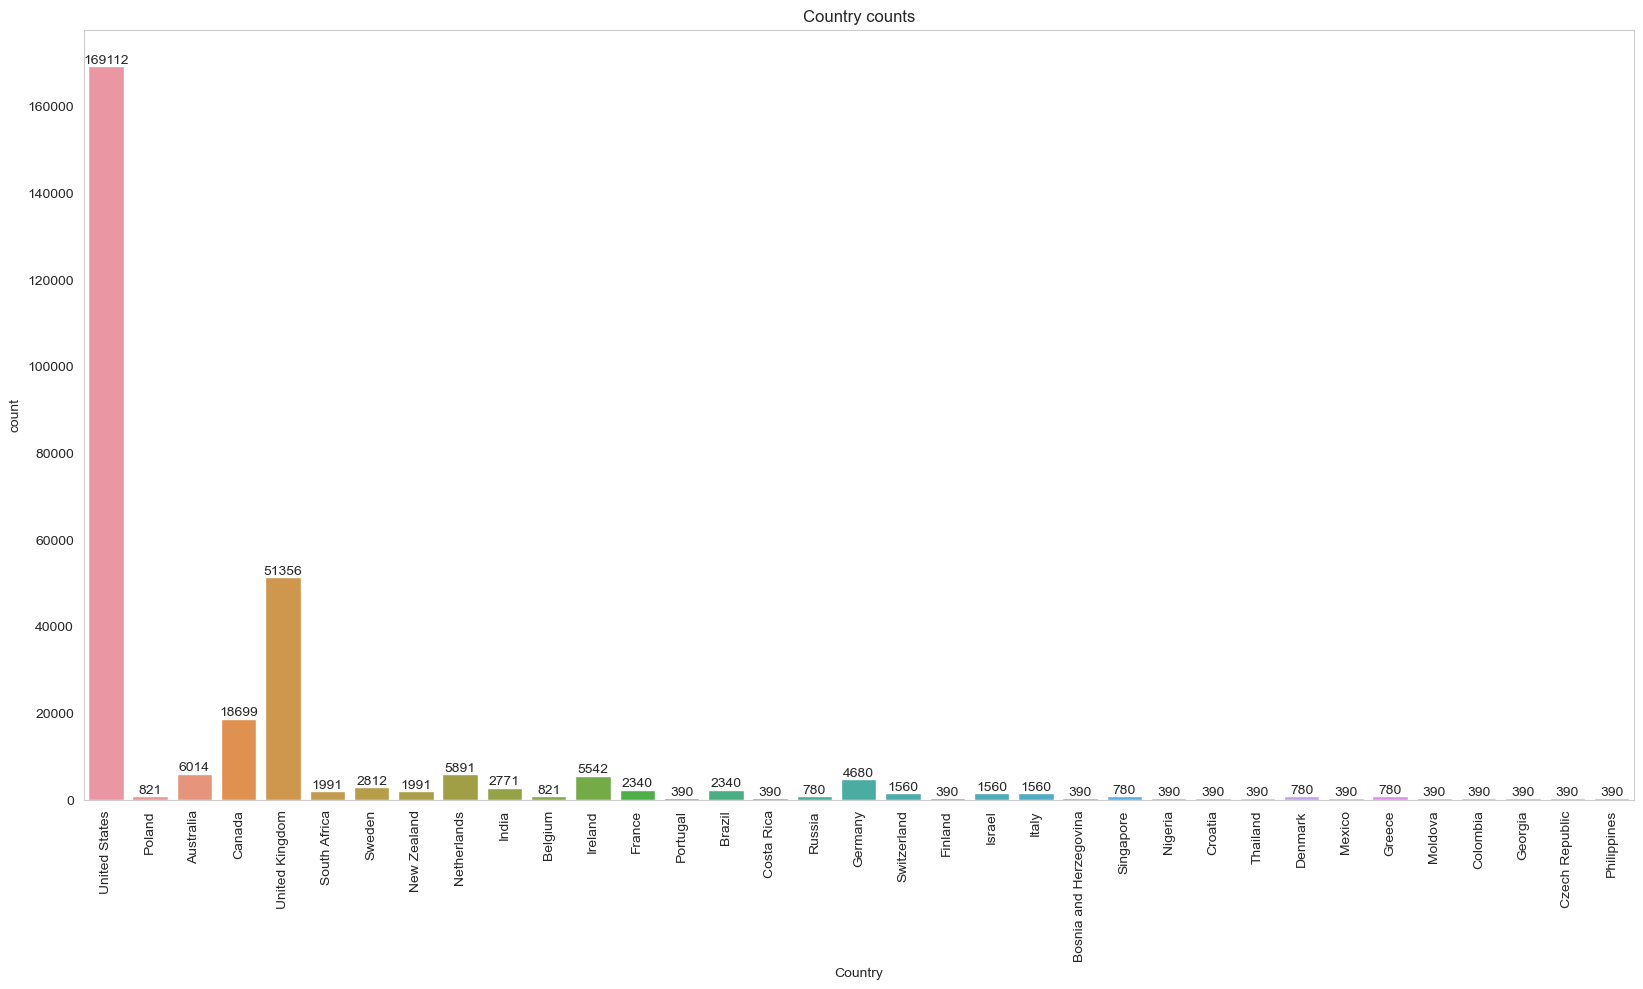

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.countplot(x='Country', data=df)
plt.xticks(rotation = 90)
for i in ax.containers:
    ax.bar_label(i)
    ax.set_title('Country counts')
    ax.grid(False)
plt.show()
plt.clf()

### 1.3.2 Bivairate Analysis

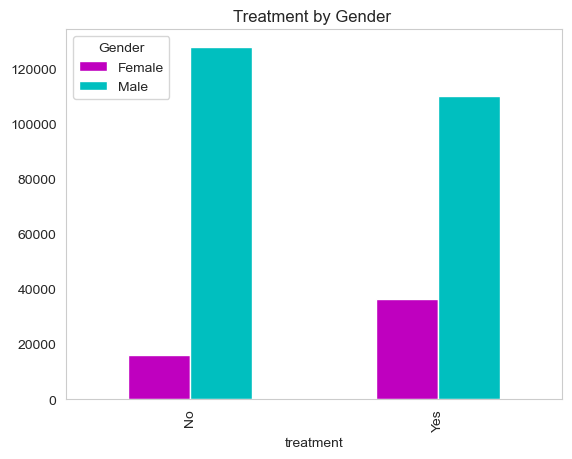

In [ ]:
ax = pd.crosstab(df['treatment'],df.Gender).plot(kind = 'bar',color = ['m','c'])
ax.grid(False)
ax.set_title('Treatment by Gender ')
plt.show()
plt.close()

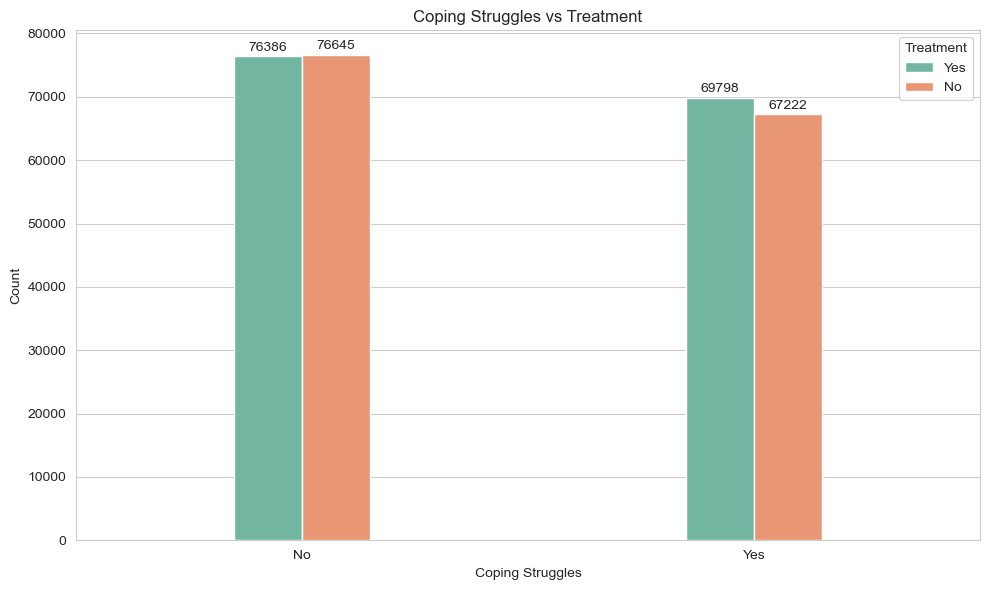

In [ ]:
plt.figure(figsize=(10,6))
ax=sns.countplot(
    data=df,
    x='Coping_Struggles',
    hue='treatment',
    palette='Set2',
     width=0.3
)
plt.title('Coping Struggles vs Treatment')
plt.xlabel('Coping Struggles')
plt.ylabel('Count')
plt.legend(title='Treatment')


for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=2)

plt.tight_layout()
plt.show()

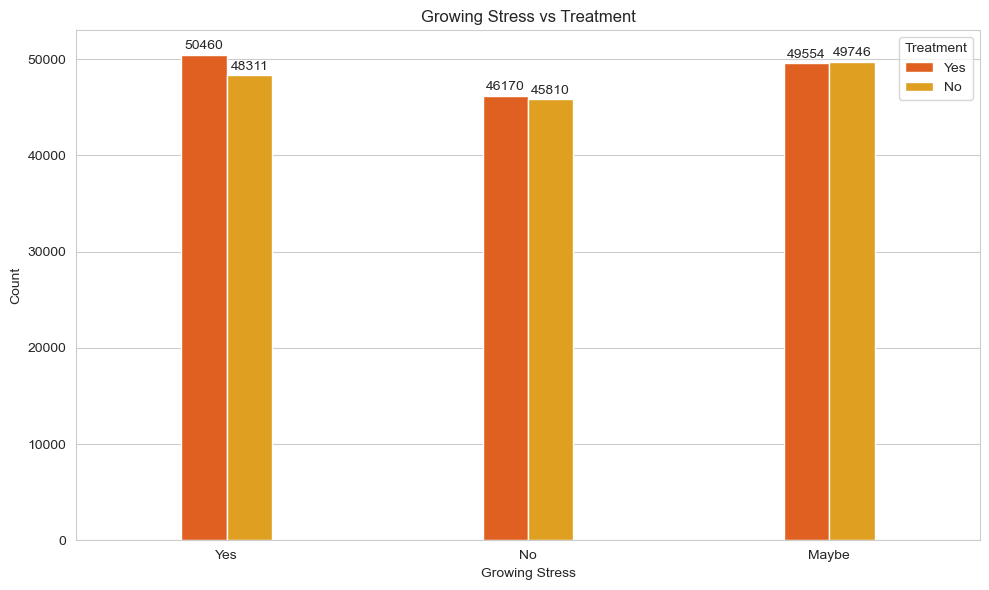

In [ ]:
plt.figure(figsize=(10,6))
ax=sns.countplot(
    data=df,
    x='Growing_Stress',
    hue='treatment',
    palette='autumn',
     width=0.3
)
plt.title('Growing Stress vs Treatment')
plt.xlabel('Growing Stress')
plt.ylabel('Count')
plt.legend(title='Treatment')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=2)
plt.tight_layout()
plt.show()

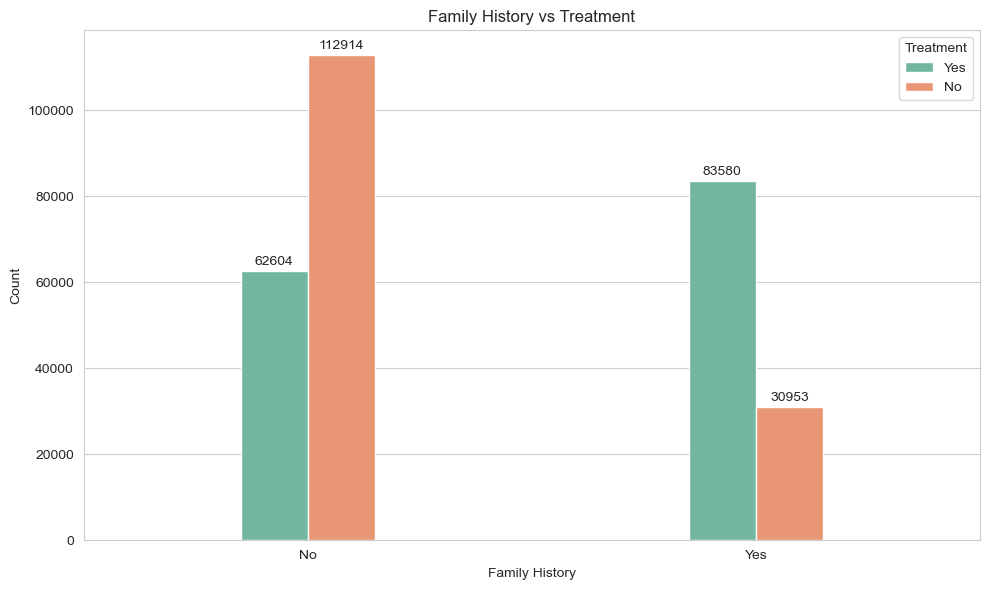

In [ ]:
plt.figure(figsize=(10,6))
ax =sns.countplot(
    data=df,
    x='family_history',
    hue='treatment',
    palette='Set2',
     width=0.3
)
plt.title('Family History vs Treatment')
plt.xlabel('Family History')
plt.ylabel('Count')
plt.legend(title='Treatment')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=2)

plt.tight_layout()
plt.show()

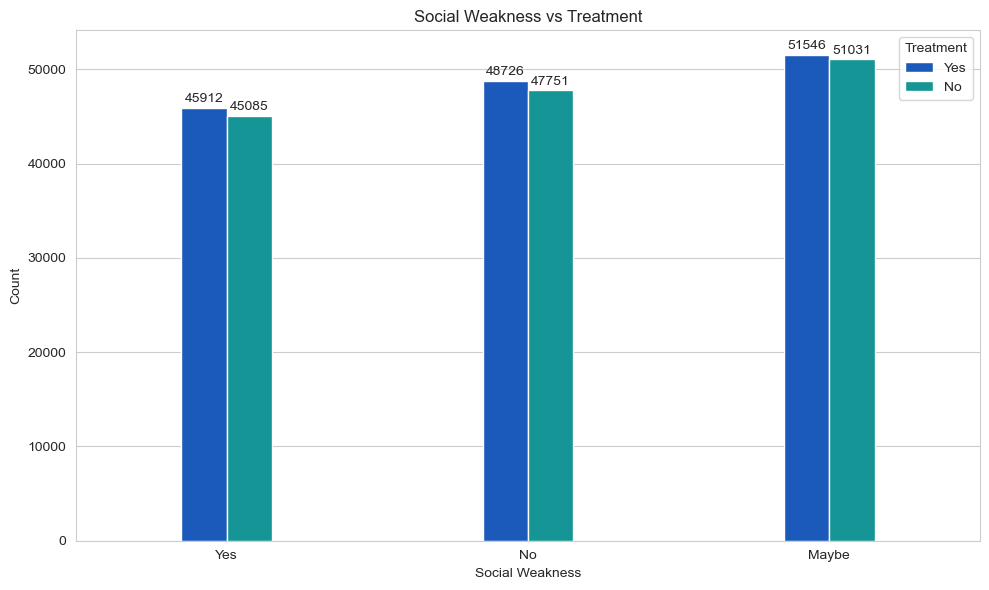

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.countplot(
    data=df,
    x='Social_Weakness',
    hue='treatment',
    palette='winter',
    width=0.3
)

plt.title('Social Weakness vs Treatment')
plt.xlabel('Social Weakness')
plt.ylabel('Count')
plt.legend(title='Treatment')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=2)

plt.tight_layout()
plt.show()


### 1.3.3 Correlation Plot

In [ ]:
num_df = df.drop(columns=['Timestamp', 'Country', 'Occupation','Gender','Days_Indoors'])
encoding_map = {'Yes': 1,'High':1,'No': 0,'Low':0, 'Maybe': 0.5,'Not sure':0.5,'Medium':0.5}
df_encoded = num_df.replace(encoding_map)
df_encoded.head()

C:\Users\magan\AppData\Local\Temp\ipykernel_112388\3389376907.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded = num_df.replace(encoding_map)


,self_employed,family_history,treatment,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,0,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.0,0.5
1,0,1,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.0,0.0
2,0,1,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.0,1.0
3,0,1,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.5,1.0
4,0,1,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.0,1.0


In [ ]:
corr_matrix = df_encoded.corr()
corr_matrix.head()

,self_employed,family_history,treatment,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
self_employed,1.000000,0.011206,0.036400,-0.002750,0.000742,-0.000482,-0.001060,-0.003814,-0.001186,0.000167,0.058220,0.042469
family_history,0.011206,1.000000,0.364737,0.008269,-0.002231,0.001449,0.003186,0.011467,0.003567,-0.000501,-0.067393,0.124208
treatment,0.036400,0.364737,1.000000,0.007378,-0.001990,0.001293,0.002842,0.010231,0.003183,-0.000447,-0.066658,0.250555
Growing_Stress,-0.002750,0.008269,0.007378,1.000000,-0.016495,0.029894,-0.007317,-0.019212,0.041083,0.034879,-0.005131,0.004424
Changes_Habits,0.000742,-0.002231,-0.001990,-0.016495,1.000000,-0.022706,-0.022053,-0.028515,0.029583,-0.002993,0.001384,-0.001193


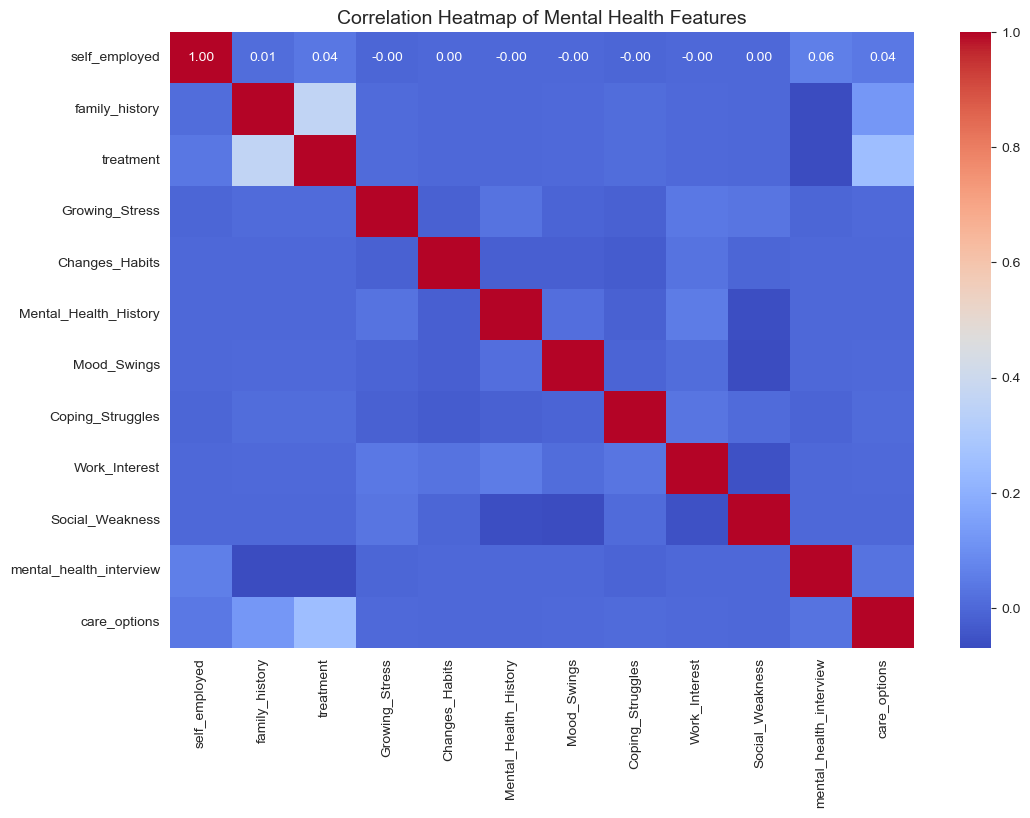

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Mental Health Features", fontsize=14)
plt.show()

This shows us that the correlation between the target variable and the other is very limited. This might be because the relationships are psychological and nonlinear, so “yes/no” answers don’t create strong categorical associations. Also i feel like models like logistic regression may perform modestly, while tree-based classifiers can still capture non-linear dependencies that simple correlation metrics miss.

## 2 Hypothesis Testing

In [ ]:
from scipy.stats import chi2_contingency

df1 = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)


In [ ]:
df1.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [ ]:
target = 'treatment'
chi2_results = []

for col in df1.columns:
    if col != target and df1[col].dtype == 'object':
        contingency_table = pd.crosstab(df1[col], df1[target])
        chi2, p, dof, ex = chi2_contingency(contingency_table)
        chi2_results.append((col, p))

chi2_df1 = pd.DataFrame(chi2_results, columns=['Feature', 'p_value']).sort_values(by='p_value')
print(chi2_df1)


                    Feature       p_value
0                 Timestamp  0.000000e+00
1                    Gender  0.000000e+00
2                   Country  0.000000e+00
5            family_history  0.000000e+00
14  mental_health_interview  0.000000e+00
15             care_options  0.000000e+00
4             self_employed  1.615584e-85
11         Coping_Struggles  3.663692e-08
7            Growing_Stress  3.013435e-07
3                Occupation  1.498487e-04
9     Mental_Health_History  2.130080e-03
6              Days_Indoors  6.712214e-02
12            Work_Interest  1.063551e-01
10              Mood_Swings  1.557198e-01
13          Social_Weakness  4.852285e-01
8            Changes_Habits  5.356398e-01


#### Results:-

The is a boost of confidence becuase we still have statistically significant variables in the dataset with the target variable as treatment.

Strong Predictors of Treatment:

Family_History, Coping_Struggles, Growing_Stress, Mental_Health_Interview, Care_Options, Mental_Health_History

Weak/Insignificant Predictors:

Changes_Habits, Mood_Swings, Social_Weakness, Days_Indoors, Work_Interest

## 3 Building the models

### 3.1 Dividing into train test and a validation set

We will be using the statistically significant variables as the features in logistic regression and decision trees to prevent overfitting

In [ ]:
df_encoded

,self_employed,family_history,treatment,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,0,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.0,0.5
1,0,1,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.0,0.0
2,0,1,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.0,1.0
3,0,1,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.5,1.0
4,0,1,1,1.0,0.0,1.0,0.5,0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
292359,1,1,1,0.0,0.5,0.0,0.0,1,0.0,0.5,0.5,0.5
292360,0,1,1,0.0,0.5,0.0,0.0,1,0.0,0.5,0.0,1.0
292361,0,1,0,0.0,0.5,0.0,0.0,1,0.0,0.5,0.0,0.0
292362,0,1,1,0.0,0.5,0.0,0.0,1,0.0,0.5,0.0,1.0


In [ ]:
features = ['family_history', 'Coping_Struggles', 'Growing_Stress',
            'mental_health_interview', 'care_options', 'Mental_Health_History']
target = 'treatment'



X = df_encoded[features]
y = df_encoded[target]


# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


Train: (203035, 6), Validation: (43508, 6), Test: (43508, 6)


### 3.2 Training the Logistic Regression and Decision Tree models

#### 3.2.1 Training a Logistic Regression Model:

Logistic Regression Accuracy (Validation): 0.7039854739358279
Precision 0.6990196078431372
Recall 0.7191783962220898
F1_score 0.7089557298140156


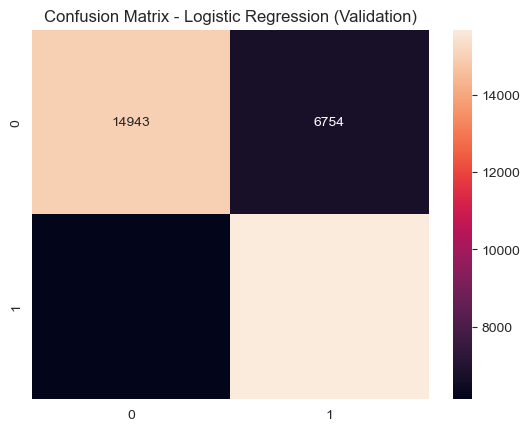

In [ ]:
# Train model
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

# Evaluate on validation set
y_pred_val_log = log_model.predict(X_val)

# Metrics
print("Logistic Regression Accuracy (Validation):", accuracy_score(y_val, y_pred_val_log))
print("Precision", precision_score(y_val, y_pred_val_log))
print("Recall",recall_score(y_val,y_pred_val_log))
print("F1_score",f1_score(y_val,y_pred_val_log))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_val, y_pred_val_log), annot=True, fmt='g')
plt.title("Confusion Matrix - Logistic Regression (Validation)")
plt.savefig('logistic_regression_heatmap.png')

# You can keep plt.show() if you still want the window to pop up
plt.show()

In [ ]:
cm = confusion_matrix(y_val, y_pred_val_log)
print(cm)

[[14943  6754]
 [ 6125 15686]]


#### 3.2.1 Training a Decision Tree

🔹 Decision Tree Accuracy (Validation): 0.7083524868989611
Precision 0.6887518622744578
Recall 0.7630553390491036
F1_score 0.7240021750951604


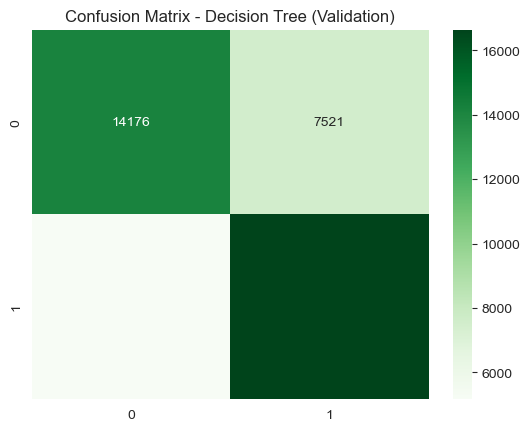

In [ ]:
# Train Decision Tree
tree_model = DecisionTreeClassifier(max_depth=12, random_state=42)
tree_model.fit(X_train, y_train)

# Evaluate on validation set
y_pred_val_tree = tree_model.predict(X_val)

print("🔹 Decision Tree Accuracy (Validation):", accuracy_score(y_val, y_pred_val_tree))
print("Precision", precision_score(y_val,y_pred_val_tree))
print("Recall",recall_score(y_val,y_pred_val_tree))
print("F1_score",f1_score(y_val,y_pred_val_tree))

sns.heatmap(confusion_matrix(y_val, y_pred_val_tree), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree (Validation)")
plt.show()


In [ ]:
cm = confusion_matrix(y_val, y_pred_val_tree)
print(cm)

[[14176  7521]
 [ 5168 16643]]


### 3.3 Results & Discussion:-


In [ ]:
y_pred_test_log = log_model.predict(X_test)
y_pred_test_tree = tree_model.predict(X_test)

print("Test Accuracy - Logistic Regression:", accuracy_score(y_test, y_pred_test_log))
print("Test Accuracy - Decision Tree:", accuracy_score(y_test, y_pred_test_tree))


Test Accuracy - Logistic Regression: 0.7065826974349545
Test Accuracy - Decision Tree: 0.7080077227176611


Here we see that the Decision tree model just slightly performs better than the logistic regression model which might be due to pure randomness

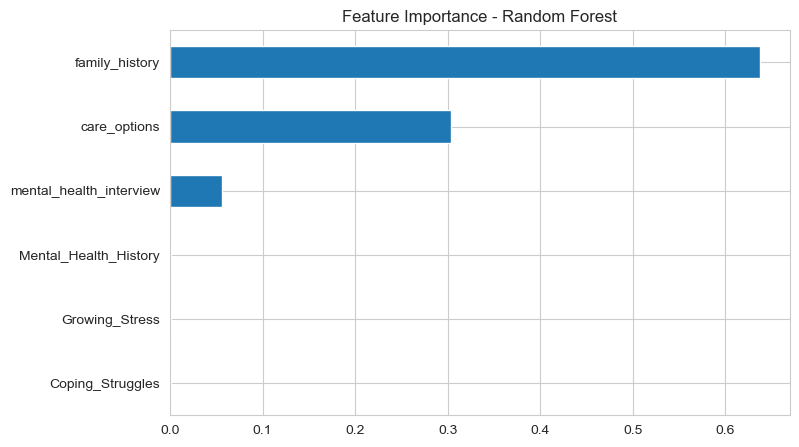

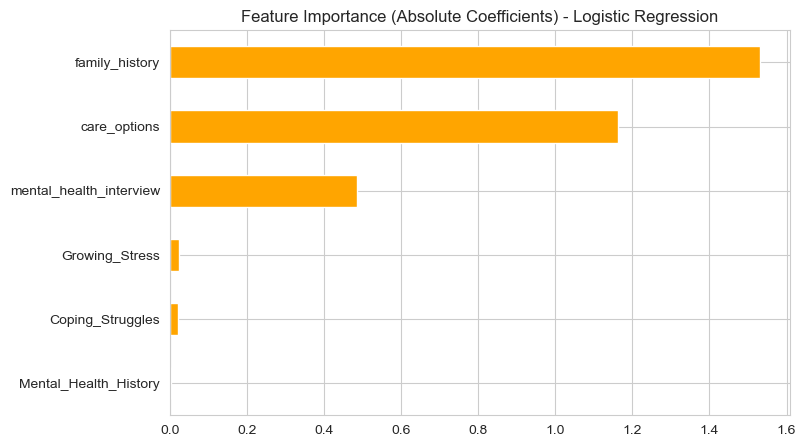

In [ ]:
tree_impor = pd.Series(tree_model.feature_importances_, index=features)
tree_impor.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance - Decision Tree")
plt.show()

coefficients = log_model.coef_[0]
log_impor = pd.Series(np.abs(coefficients), index=features)

log_impor.sort_values().plot(kind='barh', figsize=(8,5), color='orange')
plt.title("Feature Importance (Absolute Coefficients) - Logistic Regression")
plt.show()


## 4 Building an ensemble models

Now I am trying to build an ensemble model to know if I can improve my accuracy by increasing the model's complexity. We are also adding more features

In [ ]:
features = ['family_history', 'Coping_Struggles', 'Growing_Stress',
            'mental_health_interview', 'care_options', 'Mental_Health_History','Gender','Mood_Swings','Social_Weakness']
target = 'treatment'

le = LabelEncoder()

df_encoded['Gender'] = le.fit_transform(df['Gender'])

X2 = df_encoded[features]
y2 = df_encoded[target]

# 70% train, 15% val, 15% test
X_train2, X_temp2, y_train2, y_temp2 = train_test_split(X2, y2, test_size=0.30, random_state=42)
X_val2, X_test2, y_val2, y_test2 = train_test_split(X_temp2, y_temp2, test_size=0.50, random_state=42)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Train: {X_train2.shape}, Validation: {X_val2.shape}, Test: {X_test2.shape}")

Train: (203035, 6), Validation: (43508, 6), Test: (43508, 6)
Train: (203035, 9), Validation: (43508, 9), Test: (43508, 9)


### 4.1.1 Training a Random Forest Classifier

Random Forest Accuracy (Validation): 0.7097775121816677
Precision: 0.6903814262023217
Recall: 0.763467974875063
F1_score: 0.7250876314471708


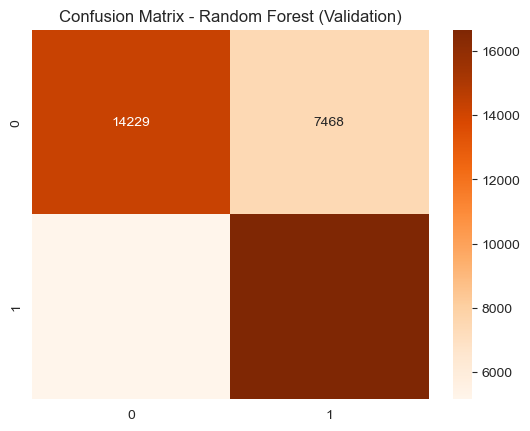

In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
rf_model.fit(X_train2, y_train2)

y_pred_val_rf = rf_model.predict(X_val2)

print("Random Forest Accuracy (Validation):", accuracy_score(y_val2, y_pred_val_rf))
print("Precision:", precision_score(y_val2, y_pred_val_rf))
print("Recall:", recall_score(y_val2, y_pred_val_rf))
print("F1_score:", f1_score(y_val2, y_pred_val_rf))

sns.heatmap(confusion_matrix(y_val2, y_pred_val_rf), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest (Validation)")
plt.show()


### 4.1.2 Training a Xgboost Classifier

C:\Users\magan\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [23:24:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy (Validation): 0.7094327480003677
Precision: 0.6902045388540845
Recall: 0.7627344000733575
F1_score: 0.7246591453587141


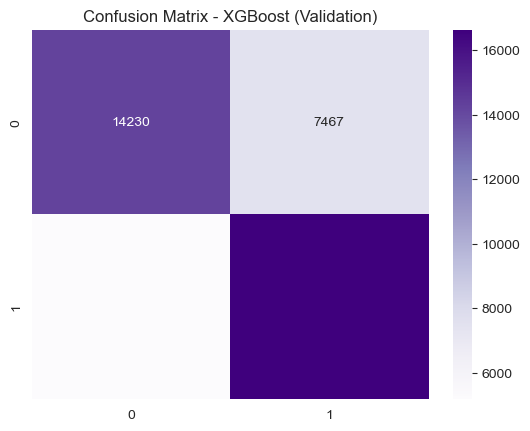

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train2, y_train2)

# Validate
y_pred_val_xgb = xgb_model.predict(X_val2)

print("XGBoost Accuracy (Validation):", accuracy_score(y_val2, y_pred_val_xgb))
print("Precision:", precision_score(y_val2, y_pred_val_xgb))
print("Recall:", recall_score(y_val2, y_pred_val_xgb))
print("F1_score:", f1_score(y_val2, y_pred_val_xgb))
sns.heatmap(confusion_matrix(y_val2, y_pred_val_xgb), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - XGBoost (Validation)")
plt.show()


### 4.1.3 Results and Discussion

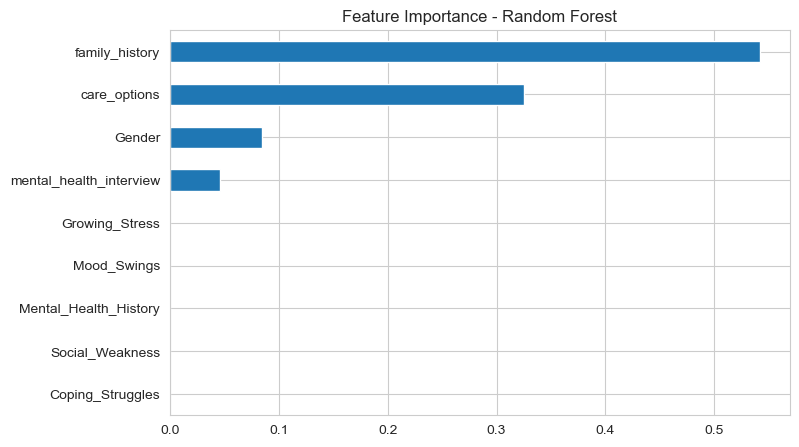

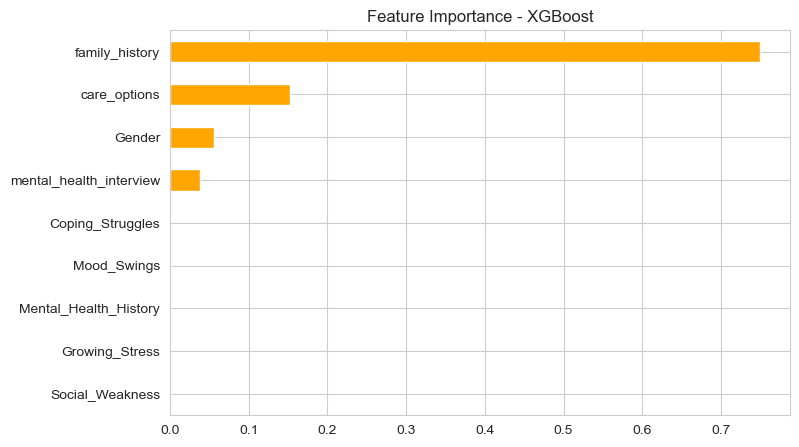

In [ ]:
# For Random Forest
rf_importances = pd.Series(rf_model.feature_importances_, index=features)
rf_importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance - Random Forest")
plt.show()

# For XGBoost
xgb_importances = pd.Series(xgb_model.feature_importances_, index=features)
xgb_importances.sort_values().plot(kind='barh', figsize=(8,5), color='orange')
plt.title("Feature Importance - XGBoost")
plt.show()


Here we notice that the feature importance for both the models is almost identical.

Also another Key finding is the the overall accuracy didn't improve on training an ensemble model

## 5 Analysis and interpretation of Results

In [ ]:
results = {
    "Logistic Regression": accuracy_score(y_val, y_pred_val_log),
    "Decision Tree": accuracy_score(y_val, y_pred_val_tree),
    "Random Forest": accuracy_score(y_val2, y_pred_val_rf),
    "XGBoost": accuracy_score(y_val2, y_pred_val_xgb)
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Validation Accuracy'])
results_df


,Model,Validation Accuracy
0,Logistic Regression,0.703985
1,Decision Tree,0.708352
2,Random Forest,0.709778
3,XGBoost,0.709433


In [ ]:
y_pred_test_log=log_model.predict(X_test)
y_pred_test_tree=tree_model.predict(X_test)
y_pred_test_rf=rf_model.predict(X_test2)
y_pred_test_xgb=xgb_model.predict(X_test2)

test_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_val_log),
    "Decision Tree": accuracy_score(y_test, y_pred_val_tree),
    "Random Forest": accuracy_score(y_test2, y_pred_val_rf),
    "XGBoost": accuracy_score(y_test2, y_pred_val_xgb)
}

test_results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Test Accuracy'])
test_results_df

,Model,Test Accuracy
0,Logistic Regression,0.703985
1,Decision Tree,0.708352
2,Random Forest,0.709778
3,XGBoost,0.709433


## 6 Conclusion

+ I observed that all models Logistic Regression, Decision Tree, Random Forest, and XGBoost plateaued around 70% validation accuracy.
+ But this convergence of all the model's performance suggests that the predictive power of the dataset has been captured correctly
+ The reason for the plateau may be that features are predominantly binary and self-reported, they offer limited variance for the models to exploit.
+ I feel like treatment is a complex variable and is influenced by complex psychological and social factors not captured in the dataset.So the dataset can be improved furthur for this purpose.